platescale = 2.0Å/pix


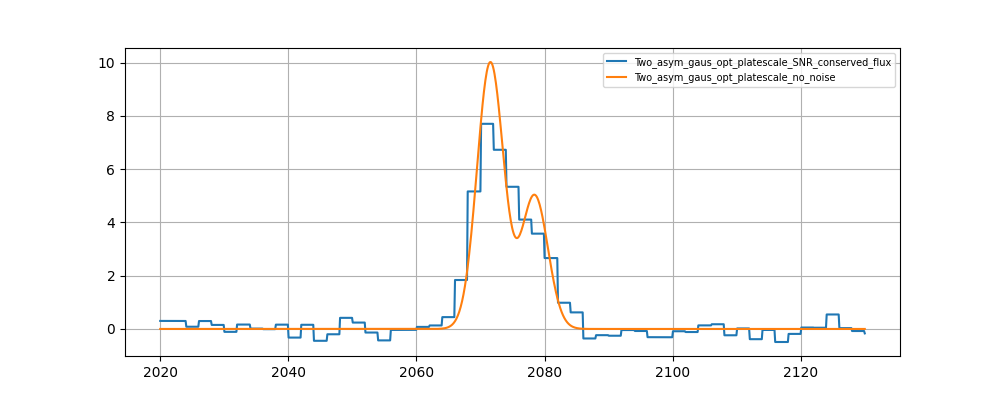

In [13]:
%matplotlib widget
%reload_ext autoreload
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from inspect import signature
from scipy.optimize import curve_fit

def rebin_y_constant_xsize(x, y, bin_width=1.0, method='mean'):
    """
    Rebin y over x with a given bin width (in same units as x), 
    keeping the same number of points as original.
    
    Parameters:
        x (array): Array of x values (must be sorted).
        y (array): Array of y values.
        bin_width (float): Width of the bin for averaging.
        method (str): 'mean' or 'median' for aggregation.
    
    Returns:
        y_rebinned (array): Rebinned y array with same size as input.
    """
    if method not in ['mean', 'median']:
        raise ValueError("Method must be 'mean' or 'median'")
    
    bins = np.floor((x - x[0]) / bin_width).astype(int)
    y_rebinned = np.zeros_like(y)

    for b in np.unique(bins):
        mask = bins == b
        if method == 'mean':
            val = y[mask].mean()
        else:
            val = np.median(y[mask])
        y_rebinned[mask] = val

    return y_rebinned

# Example asymmetric Gaussian function

def entry_spectra(x=np.linspace(2020, 2130, 1000),
                  A_b=[-1.3, 1.3, 0.7],
                  w=[2020, 2130, 2075],
                  speed=[0, 2500, 1000],
                  sigma_b=[10, 1000, 300],
                  A_r=[-1.3, 1.3, 0.7],
                  sigma_r=[10, 1000, 100],):
    
    wave = np.mean(x)
    factor = wave / 3e5  # Use 3e5 (km/s) instead of 3e6 (m/s) for speed in km/s
    
    spectra = A_b * np.exp(-0.5 * ((x - w - factor * speed / 2) / (factor * sigma_b)) ** 2) + \
              A_r * np.exp(-0.5 * ((x - w + factor * speed / 2) / (factor * sigma_r)) ** 2)
        
    return spectra


def Two_asym_gaus(x=np.linspace(2020, 2130, 1000),
                  A_b=[-1.3, 1.3, 0.7],
                  w=[2020, 2130, 2075],
                  speed=[0, 2500, 1000],
                  sigma_b=[10, 1000, 300],
                  A_r=[-1.3, 1.3, 0.7],
                  sigma_r=[10, 1000, 100],
                  dl=[0.01, 10, 0.5],
                  platescale=[0.1, 10, 0.5]):
    
    wave = np.mean(x)
    factor = wave / 3e5  # Use 3e5 (km/s) instead of 3e6 (m/s) for speed in km/s
    dx = np.mean(np.diff(x)) 
    
    spectra = entry_spectra(x=x,A_b=A_b,w=w,speed=speed,sigma_b=sigma_b,A_r=A_r,sigma_r=sigma_r)
    
    convolved_spectra = gaussian_filter1d(spectra, dl / (2.3548 * dx), mode='nearest')
    sampled_spectra = rebin_y_constant_xsize(x, convolved_spectra, bin_width=platescale)
    
    return sampled_spectra


def Two_asym_gaus_opt_platescale(x=np.linspace(2020, 2130, 1000),
                  A_b=[-1.3, 1.3, 0.7],
                  w=[2020, 2130, 2075],
                  speed=[0, 2500, 1000],
                  sigma_b=[10, 1000, 300],
                  A_r=[-1.3, 1.3, 0.7],
                  sigma_r=[10, 1000, 100],
                #   dl=[0.01, 10, 0.5],
                #   platescale=[0.1, 10, 0.5]):
    R=[200,10000,500]):
    dl = 2000/R
    platescale = dl/2
    return Two_asym_gaus(x=x,A_b=A_b,w=w,speed=speed,sigma_b=sigma_b,A_r=A_r,sigma_r=sigma_r,dl=dl,platescale=platescale)



def Two_asym_gaus_opt_platescale_noise_conserved_flux(x=np.linspace(2020, 2130, 1000),
                  A_b=[-1.3, 1.3, 0.7],
                  w=[2020, 2130, 2075],
                  speed=[0, 2500, 1000],
                  sigma_b=[10, 1000, 300],
                  A_r=[-1.3, 1.3, 0.7],
                  sigma_r=[10, 1000, 100],
                #   dl=[0.01, 10, 0.5],
                #   platescale=[0.1, 10, 0.5]):
    R=[200,10000,500],
    Noise = [0,1,0.1]
    ):
    dl = 2000/R
    platescale = dl/2
    print("platescale = %0.1fÅ/pix"%(platescale) )
    noise = rebin_y_constant_xsize(x, np.random.normal(0,Noise,size=len(x)),bin_width=platescale )
    return Two_asym_gaus(x=x,A_b=A_b*platescale,A_r=A_r*platescale,w=w,speed=speed,sigma_b=sigma_b,sigma_r=sigma_r,dl=dl,platescale=platescale) +noise



def Two_asym_gaus_opt_platescale_SNR_conserved_flux(x=np.linspace(2020, 2130, 1000),
                #   A_b=[-1.3, 1.3, 0.7],
                  w=[2020, 2130, 2075],
                  speed=[0, 2500, 1000],
                  sigma_b=[10, 1000, 300],
                  SNR=[0, 100, 5],
                #   A_r=[-1.3, 1.3, 0.7],
                #   dl=[0.01, 10, 0.5],
                #   platescale=[0.1, 10, 0.5]):
                # Noise = [0,1,0.1])
                R=[200,10000,500]  )   :
    Noise = 1
    A_b = SNR*Noise/2
    A_r = SNR*Noise
    dl = 2000/R
    platescale = dl/2
    noise = rebin_y_constant_xsize(x, np.random.normal(0,Noise,size=len(x)),bin_width=platescale )
    return Two_asym_gaus(x=x,A_b=A_b*platescale,A_r=A_r*platescale,w=w,speed=speed,sigma_b=sigma_b,sigma_r=sigma_b,dl=dl,platescale=platescale) +noise


def Two_asym_gaus_opt_platescale_no_noise(x=np.linspace(2020, 2130, 1000),
                  w=[2020, 2130, 2075],
                  speed=[0, 2500, 1000],
                  sigma_b=[10, 1000, 300],
                  SNR=[0, 100, 5],
                R=[200,10000,500]  )   :
    Noise = 1
    A_b = SNR*Noise/2
    A_r = SNR*Noise
    dl = 2000/R
    platescale = dl/2
    print("platescale = %0.1fÅ/pix"%(platescale) )
    return entry_spectra(x=x,A_b=A_b*platescale,w=w,speed=speed,sigma_b=sigma_b,A_r=A_r*platescale,sigma_r=sigma_b)



import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from inspect import signature
from IPython.display import display

def get_param_widgets(func):
    widgets_dict = {}
    sig = signature(func)
    for name, param in sig.parameters.items():
        if name == "x":
            continue
        default = param.default
        if isinstance(default, (list, tuple)) and len(default) == 3:
            min_val, max_val, default_val = default
            widgets_dict[name] = widgets.FloatSlider(
                value=default_val,
                min=min_val,
                max=max_val,
                step=(max_val - min_val) / 100,
                description=name,
                continuous_update=True,
                readout_format='.3f',
                layout=widgets.Layout(width='500px')
            )
    return widgets_dict

def get_default_kwargs(func, x=False):
    sig = signature(func)
    kwargs = {}
    for name, param in sig.parameters.items():
        if name == "x":
            if x:
                return param.default
            else:
                continue
        default = param.default
        if isinstance(default, (list, tuple)) and len(default) == 3:
            kwargs[name] = default[2]
    return kwargs

def fit_function(func):
    # Accepter une seule fonction ou un tuple
    funcs = func if isinstance(func, (list, tuple)) else (func,)

    # On suppose que toutes les fonctions ont les mêmes paramètres
    param_widgets = get_param_widgets(funcs[0])
    default_kwargs = get_default_kwargs(funcs[0])
    x = get_default_kwargs(funcs[0], x=True)

    # Initialisation du graphique
    fig, ax = plt.subplots(figsize=(10, 4))
    lines = []
    for f in funcs:
        y = f(x=x, **default_kwargs)
        (line,) = ax.plot(x, y, label=f.__name__)
        lines.append(line)
    ax.grid(True)
    ax.legend(loc="upper right", fontsize=7)
    plt.show()

    # Fonction de mise à jour
    def update(**kwargs):
        for i, f in enumerate(funcs):
            y_new = f(x=x, **kwargs)
            lines[i].set_ydata(y_new)
        ax.relim()
        ax.autoscale_view()

    # Widgets + output
    ui = widgets.VBox(list(param_widgets.values()))
    out = widgets.interactive_output(update, param_widgets)
    display(widgets.VBox([ui, out]))

fit_function(func=(Two_asym_gaus_opt_platescale_SNR_conserved_flux, Two_asym_gaus_opt_platescale_no_noise))
# plot_interactive_gaussian(Two_asym_gaus)
# plot_interactive_gaussian(Two_asym_gaus_opt_platescale_noise_conserved_flux)


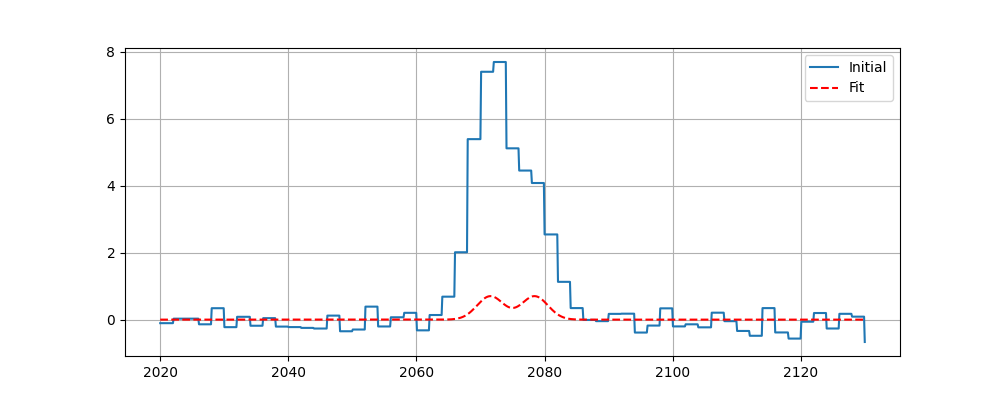

In [14]:

def simplified_entry_spectra(x=np.linspace(2020, 2130, 1000),
                  A_b=[-1.3, 1.3, 0.7],
                  w=[2020, 2130, 2075],
                  speed=[0, 2500, 1000],
                  sigma_b=[10, 1000, 300],
                  A_r=[-1.3, 1.3, 0.7],):
                #   sigma_r=[10, 1000, 100],
    
    wave = np.mean(x)
    factor = wave / 3e5  # Use 3e5 (km/s) instead of 3e6 (m/s) for speed in km/s
    
    spectra = A_b * np.exp(-0.5 * ((x - w - factor * speed / 2) / (factor * sigma_b)) ** 2) + \
              A_r * np.exp(-0.5 * ((x - w + factor * speed / 2) / (factor * sigma_b)) ** 2)
        
    return spectra


def get_param_widgets(func):
    widgets_dict = {}
    sig = signature(func)
    for name, param in sig.parameters.items():
        if name == "x":
            continue
        default = param.default
        if isinstance(default, (list, tuple)) and len(default) == 3:
            min_val, max_val, default_val = default
            widgets_dict[name] = widgets.FloatSlider(
                value=default_val,
                min=min_val,
                max=max_val,
                step=(max_val - min_val) / 100,
                description=name,
                continuous_update=True,
                readout_format='.3f',
                layout=widgets.Layout(width='500px')
            )
    return widgets_dict

def get_default_kwargs(func, x=False):
    sig = signature(func)
    kwargs = {}
    for name, param in sig.parameters.items():
        if name == "x":
            if x:
                return param.default
            else:
                continue
        default = param.default
        if isinstance(default, (list, tuple)) and len(default) == 3:
            kwargs[name] = default[2]
    return kwargs

def flatten_kwargs(kwargs):
    flat = []
    shapes = {}
    for key, val in kwargs.items():
        if isinstance(val, (list, tuple, np.ndarray)):
            shapes[key] = len(val)
            flat.extend(val)
        else:
            shapes[key] = 1
            flat.append(val)
    return np.array(flat), shapes

def unflatten_kwargs(flat, shapes):
    result = {}
    i = 0
    for key, count in shapes.items():
        if count == 1:
            result[key] = flat[i]
            i += 1
        else:
            result[key] = list(flat[i:i + count])
            i += count
    return result

def plot_interactive_gaussian(entry, fitting_function):
    param_widgets = get_param_widgets(entry)
    default_kwargs = get_default_kwargs(entry)
    x = get_default_kwargs(entry, x=True)
    y = entry(x=x, **default_kwargs)

    fig, ax = plt.subplots(figsize=(10, 4))
    (line,) = ax.plot(x, y, label='Initial')
    fit_line, = ax.plot(x, fitting_function(x=x, **get_default_kwargs(fitting_function)), '--', label='Fit', color='red')
    ax.grid(True)
    ax.legend()
    plt.show()

    def update(**kwargs):
        y = entry(x=x, **kwargs)
        line.set_ydata(y)
        ax.relim()
        ax.autoscale_view()

    ui = widgets.VBox(list(param_widgets.values()))
    out = widgets.interactive_output(update, param_widgets)

    # Button for fitting
    fit_button = widgets.Button(description="Fit", button_style='primary')

    def on_fit_clicked(b):
        current_entry_kwargs = {k: w.value for k, w in param_widgets.items()}
        y_current = entry(x=x, **current_entry_kwargs)

        # Prépare les paramètres du modèle de fit
        fit_widgets = get_param_widgets(fitting_function)
        p0, shapes = flatten_kwargs({k: w.value for k, w in fit_widgets.items()})
        popt, _ = curve_fit(fitting_function, x, y_current, p0=p0)
        fitted_params = unflatten_kwargs(popt, shapes)

        y_fit = fitting_function(x=x, **fitted_params)
        fit_line.set_ydata(y_fit)
        ax.relim()
        ax.autoscale_view()


    fit_button.on_click(on_fit_clicked)

    display(widgets.VBox([ui, fit_button, out]))

plot_interactive_gaussian(entry=Two_asym_gaus_opt_platescale_SNR_conserved_flux,
                        fitting_function=simplified_entry_spectra) 